In [13]:
pip install ultralytics opencv-python numpy

Note: you may need to restart the kernel to use updated packages.


In [14]:
import cv2          
import numpy as np  
from ultralytics import YOLO  

In [15]:
model = YOLO("yolov8n-pose.pt")


In [16]:
import cv2
cap = cv2.VideoCapture(0)
print("Camera opened!")
print("Press Q to quit")
while True:
    ret, frame = cap.read()
    if not ret:
        print("Camera not working!")
        break
    results = model(frame, verbose=False)
    annotated_frame = results[0].plot()
    cv2.imshow("Pose Detection", annotated_frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()
print("Camera closed!")

Camera opened!
Press Q to quit
Camera closed!


In [17]:
import cv2

cap = cv2.VideoCapture(0)
print("Press Q to quit")
while True:
    ret, frame = cap.read()
    if not ret:
        break
    results = model(frame, verbose=False)
    if results[0].keypoints is not None:
        
        keypoints = results[0].keypoints.xy[0]
        names = [
            "nose", "left_eye", "right_eye",
            "left_ear", "right_ear",
            "left_shoulder", "right_shoulder",
            "left_elbow", "right_elbow",
            "left_wrist", "right_wrist",
            "left_hip", "right_hip",
            "left_knee", "right_knee",
            "left_ankle", "right_ankle"
        ]
        print("\n--- Your Body Keypoints ---")
        for i, name in enumerate(names):
            x = keypoints[i][0].item()  
            y = keypoints[i][1].item()  
            print(f"{name:20s} → x: {x:.1f}, y: {y:.1f}")
    annotated_frame = results[0].plot()
    cv2.imshow("Pose Detection", annotated_frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

Press Q to quit

--- Your Body Keypoints ---
nose                 → x: 399.2, y: 258.2
left_eye             → x: 428.3, y: 227.0
right_eye            → x: 365.8, y: 225.6
left_ear             → x: 461.3, y: 241.8
right_ear            → x: 317.2, y: 239.8
left_shoulder        → x: 509.3, y: 385.9
right_shoulder       → x: 243.3, y: 385.6
left_elbow           → x: 560.8, y: 480.0
right_elbow          → x: 181.8, y: 480.0
left_wrist           → x: 554.1, y: 476.5
right_wrist          → x: 232.1, y: 480.0
left_hip             → x: 432.9, y: 480.0
right_hip            → x: 291.7, y: 480.0
left_knee            → x: 421.7, y: 463.7
right_knee           → x: 328.9, y: 419.8
left_ankle           → x: 380.2, y: 480.0
right_ankle          → x: 442.4, y: 408.2

--- Your Body Keypoints ---
nose                 → x: 398.1, y: 258.0
left_eye             → x: 427.5, y: 227.0
right_eye            → x: 364.9, y: 225.7
left_ear             → x: 461.8, y: 242.3
right_ear            → x: 318.1, y: 240.4
le

In [18]:
import cv2

cap = cv2.VideoCapture(0)
print("Press Q to quit")
print("Move your right arm and watch the numbers change!\n")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    results = model(frame, verbose=False)
    if results[0].keypoints is not None:        
        keypoints = results[0].keypoints.xy[0]

        right_shoulder = keypoints[6]
        right_elbow    = keypoints[8]
        right_wrist    = keypoints[10]

        print(f"Shoulder → x: {right_shoulder[0]:.0f}, y: {right_shoulder[1]:.0f}")
        print(f"Elbow    → x: {right_elbow[0]:.0f},    y: {right_elbow[1]:.0f}")
        print(f"Wrist    → x: {right_wrist[0]:.0f},    y: {right_wrist[1]:.0f}")
        if right_wrist[1] < right_shoulder[1]:
            print("ARM IS RAISED (possible serve or smash!)")
        else:
            print("Arm is low (forehand or backhand)")
        print("─" * 40)
    annotated_frame = results[0].plot()
    cv2.imshow("Pose Detection", annotated_frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

Press Q to quit
Move your right arm and watch the numbers change!

Shoulder → x: 237, y: 388
Elbow    → x: 175,    y: 480
Wrist    → x: 227,    y: 480
Arm is low (forehand or backhand)
────────────────────────────────────────
Shoulder → x: 239, y: 387
Elbow    → x: 177,    y: 480
Wrist    → x: 228,    y: 480
Arm is low (forehand or backhand)
────────────────────────────────────────
Shoulder → x: 238, y: 387
Elbow    → x: 179,    y: 480
Wrist    → x: 229,    y: 480
Arm is low (forehand or backhand)
────────────────────────────────────────
Shoulder → x: 238, y: 387
Elbow    → x: 179,    y: 480
Wrist    → x: 229,    y: 480
Arm is low (forehand or backhand)
────────────────────────────────────────
Shoulder → x: 238, y: 387
Elbow    → x: 178,    y: 480
Wrist    → x: 233,    y: 479
Arm is low (forehand or backhand)
────────────────────────────────────────
Shoulder → x: 239, y: 388
Elbow    → x: 176,    y: 480
Wrist    → x: 227,    y: 478
Arm is low (forehand or backhand)
────────────────────

In [19]:
import cv2
import numpy as np

def calculate_angle(a, b, c):    
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    ba = a - b  
    bc = c - b  
    cosine_angle = np.dot(ba, bc) / (
        np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6
    )
    angle = np.degrees(np.arccos(
        np.clip(cosine_angle, -1.0, 1.0)
    ))
    return round(angle, 1)

cap = cv2.VideoCapture(0)
print("Press Q to quit")
print("Try different arm positions!\n")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    results = model(frame, verbose=False)
    if results[0].keypoints is not None:
        keypoints = results[0].keypoints.xy[0].cpu().numpy()
        right_shoulder = keypoints[6]
        right_elbow    = keypoints[8]
        right_wrist    = keypoints[10]

        angle = calculate_angle(
            right_shoulder,
            right_elbow,
            right_wrist
        )

        arm_raised = right_wrist[1] < right_shoulder[1]

        print(f"Elbow Angle : {angle}°")
        print(f"Arm Raised  : {arm_raised}")

        if arm_raised:
            print("OVERHEAD SHOT (Serve or Smash)")
        elif angle > 150:
            print("FOREHAND")
        else:
            print("BACKHAND")

        print("─" * 40)

        # Draw angle on video frame
        cv2.putText(
            frame,
            f"Angle: {angle}",
            (50, 50),                    # position on screen
            cv2.FONT_HERSHEY_SIMPLEX,    # font
            1,                           # size
            (0, 255, 0),                 # green color
            2                            # thickness
        )
    annotated_frame = results[0].plot()
    cv2.imshow("Pose Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

Press Q to quit
Try different arm positions!

Elbow Angle : 47.79999923706055°
Arm Raised  : False
BACKHAND
────────────────────────────────────────
Elbow Angle : 48.400001525878906°
Arm Raised  : False
BACKHAND
────────────────────────────────────────
Elbow Angle : 53.29999923706055°
Arm Raised  : False
BACKHAND
────────────────────────────────────────
Elbow Angle : 50.900001525878906°
Arm Raised  : False
BACKHAND
────────────────────────────────────────
Elbow Angle : 48.099998474121094°
Arm Raised  : False
BACKHAND
────────────────────────────────────────
Elbow Angle : 50.900001525878906°
Arm Raised  : False
BACKHAND
────────────────────────────────────────
Elbow Angle : 52.900001525878906°
Arm Raised  : False
BACKHAND
────────────────────────────────────────
Elbow Angle : 54.79999923706055°
Arm Raised  : False
BACKHAND
────────────────────────────────────────
Elbow Angle : 53.900001525878906°
Arm Raised  : False
BACKHAND
────────────────────────────────────────
Elbow Angle : 51.2000

In [20]:
import cv2
import numpy as np

def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)
    ba = a - b
    bc = c - b
    cosine_angle = np.dot(ba, bc) / (
        np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6
    )
    angle = np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))
    return round(angle, 1)

def classify_shot(keypoints):
    right_shoulder = keypoints[6]
    right_elbow    = keypoints[8]
    right_wrist    = keypoints[10]

    arm_raised = right_wrist[1] < right_shoulder[1]

    angle = calculate_angle(
        right_shoulder,
        right_elbow,
        right_wrist
    )

    if arm_raised:
        return "OVERHEAD (Serve/Smash)", (0, 255, 255)  
    elif angle > 150:
        return "FOREHAND", (0, 255, 0)                  
    else:
        return "BACKHAND", (0, 0, 255)                  

cap = cv2.VideoCapture(0)
print("Press Q to quit")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    results = model(frame, verbose=False)
    if results[0].keypoints is not None:
        keypoints = results[0].keypoints.xy[0].cpu().numpy()
        if keypoints.sum() > 0:
            shot_name, color = classify_shot(keypoints)
            cv2.putText(
                frame,
                f"SHOT: {shot_name}",
                (30, 60),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.2,     # font size
                color,   # color changes per shot
                3        # thickness
            )

            angle = calculate_angle(
                keypoints[6],
                keypoints[8],
                keypoints[10]
            )
            cv2.putText(
                frame,
                f"Elbow Angle: {angle}",
                (30, 110),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255, 255, 255),  # white
                2
            )

    annotated = results[0].plot(img=frame)
    cv2.imshow("Padel Shot Classifier", annotated)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

Press Q to quit


In [21]:
import cv2
import numpy as np

def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)
    ba = a - b
    bc = c - b
    cosine_angle = np.dot(ba, bc) / (
        np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6
    )
    angle = np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))
    return round(angle, 1)

def classify_shot(keypoints, is_rally_active):
    right_shoulder = keypoints[6]
    right_elbow    = keypoints[8]
    right_wrist    = keypoints[10]
    hip_center_x   = (keypoints[11][0] + keypoints[12][0]) / 2

    arm_raised = right_wrist[1] < right_shoulder[1]
    angle      = calculate_angle(right_shoulder, right_elbow, right_wrist)

    if arm_raised:
        if not is_rally_active:
            return "SERVE", True
        else:
            return "SMASH", True
    elif angle > 150:
        return "FOREHAND", is_rally_active
    else:
        return "BACKHAND", is_rally_active

video_path = "C:/Users/Lenovo/Downloads/input_sample_video.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Video not found! Check your path.")
else:
    print("Video loaded!")
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS)
    print(f"Total Frames : {total_frames}")
    print(f"FPS          : {fps}")
    print(f"Duration     : {round(total_frames/fps, 1)} seconds")

Video loaded!
Total Frames : 8125
FPS          : 25.0
Duration     : 325.0 seconds


In [22]:
cap = cv2.VideoCapture(r"C:\Users\Lenovo\Downloads\input_sample_video.mp4")

ret, frame = cap.read()
results = model(frame, verbose=False)

print(f"People detected : {len(results[0].keypoints.xy)}")
print(f"Keypoints shape : {results[0].keypoints.xy.shape}")
print(f"\nFirst person keypoints:")
print(results[0].keypoints.xy[0])

cap.release()

People detected : 2
Keypoints shape : torch.Size([2, 17, 2])

First person keypoints:
tensor([[672.7621, 700.8191],
        [670.2661, 697.5261],
        [674.7112, 694.4745],
        [665.6815, 705.2947],
        [692.1808, 696.4029],
        [666.7486, 731.5257],
        [713.7346, 719.7039],
        [674.0297, 756.2642],
        [754.0261, 746.0641],
        [695.0967, 732.9816],
        [777.7655, 744.1429],
        [708.8464, 786.8355],
        [737.6994, 783.2174],
        [740.3464, 783.1743],
        [759.8286, 778.3894],
        [747.7322, 823.5653],
        [756.8912, 813.4667]], device='cuda:0')


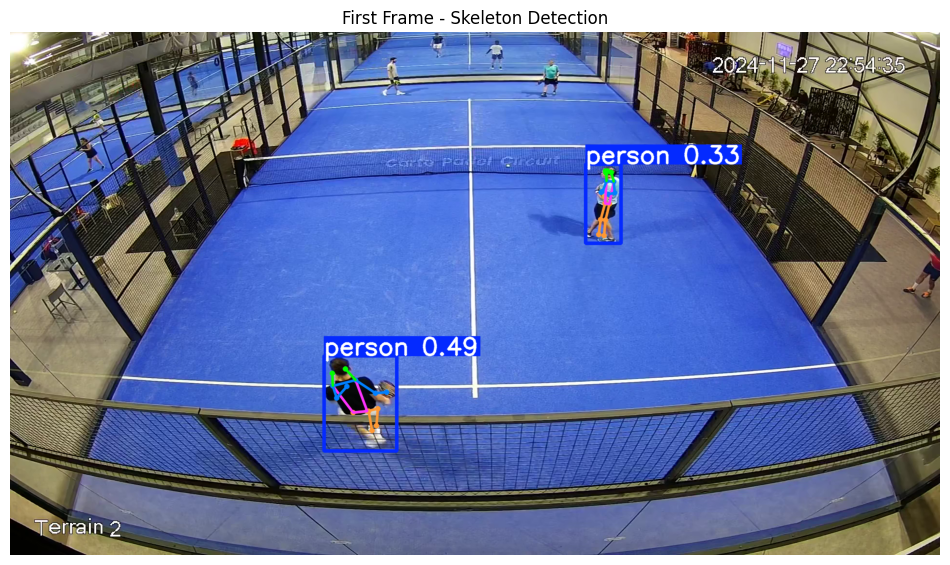

In [23]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(r"C:\Users\Lenovo\Downloads\input_sample_video.mp4")
ret, frame = cap.read()
results = model(frame, verbose=False)
annotated = results[0].plot()
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_rgb)
plt.title("First Frame - Skeleton Detection")
plt.axis("off")
plt.show()
cap.release()

In [26]:
import cv2
import numpy as np
import pandas as pd

def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)
    ba = a - b
    bc = c - b
    cosine_angle = np.dot(ba, bc) / (
        np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6
    )
    angle = np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))
    return round(angle, 1)

def classify_shot(keypoints, is_rally_active):
    right_shoulder = keypoints[6]
    right_elbow    = keypoints[8]
    right_wrist    = keypoints[10]

    arm_raised = right_wrist[1] < right_shoulder[1]
    angle      = calculate_angle(right_shoulder, right_elbow, right_wrist)

    if arm_raised:
        if not is_rally_active:
            return "SERVE", True
        else:
            return "SMASH", True
    elif angle > 150:
        return "FOREHAND", is_rally_active
    else:
        return "BACKHAND", is_rally_active

cap         = cv2.VideoCapture(r"C:\Users\Lenovo\Desktop\Badminton\input_sample_video (1).mp4")
fps         = cap.get(cv2.CAP_PROP_FPS)
width       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total       = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    r"C:\Users\Lenovo\Downloads\output_padel.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)
shot_results   = []
is_rally_active = False
frame_number   = 0

colors = {
    "SERVE"    : (0, 255, 255),   # yellow
    "SMASH"    : (0, 0, 255),     # red
    "FOREHAND" : (0, 255, 0),     # green
    "BACKHAND" : (255, 0, 0),     # blue
}
print("Processing video...")
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_number += 1
    if frame_number % 500 == 0:
        print(f"  Frame {frame_number} / {total}")
    results = model(frame, verbose=False)
    if results[0].keypoints is not None:
        all_keypoints = results[0].keypoints.xy.cpu().numpy()
        for player_idx, keypoints in enumerate(all_keypoints):
            if keypoints.sum() == 0:
                continue

            shot, is_rally_active = classify_shot(keypoints, is_rally_active)
            shot_results.append({
                "frame"         : frame_number,
                "timestamp_sec" : round(frame_number / fps, 2),
                "player"        : player_idx + 1,
                "shot"          : shot,
            })

            head_x = int(keypoints[0][0])  # nose x
            head_y = int(keypoints[0][1])  # nose y

            cv2.putText(
                frame,
                f"P{player_idx+1}: {shot}",
                (head_x - 50, head_y - 20),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                colors[shot],
                2
            )

    annotated = results[0].plot(img=frame)
    out.write(annotated)

cap.release()
out.release()
print(f"\n Done! Processed {frame_number} frames")
print(f" Output video saved!")

df = pd.DataFrame(shot_results)
df.to_csv(r"C:\Users\Lenovo\Downloads\shot_results.csv", index=False)
print(f" CSV saved!")
print(f"\nShot counts:")
print(df["shot"].value_counts())

Processing video...
  Frame 500 / 8125
  Frame 1000 / 8125
  Frame 1500 / 8125
  Frame 2000 / 8125
  Frame 2500 / 8125
  Frame 3000 / 8125
  Frame 3500 / 8125
  Frame 4000 / 8125
  Frame 4500 / 8125
  Frame 5000 / 8125
  Frame 5500 / 8125
  Frame 6000 / 8125
  Frame 6500 / 8125
  Frame 7000 / 8125
  Frame 7500 / 8125
  Frame 8000 / 8125

 Done! Processed 8125 frames
 Output video saved!
 CSV saved!

Shot counts:
shot
FOREHAND    7007
BACKHAND    5208
SMASH        963
SERVE          1
Name: count, dtype: int64


In [25]:
pip install pandas


  Using cached pandas-3.0.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.3-cp311-cp311-win_amd64.whl (9.9 MB)
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)

   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
 